# Reconsitution des fonctions des expériences

https://web.eecs.utk.edu/~dcostine/personal/PowerDeviceLib/DigiTest/index.html

In [1]:
import numpy as np
from scipy.optimize import curve_fit
import warnings
import matplotlib.pyplot as plt
import pandas as pd

# 1. Familles de fonctions GOW (normalisées : f(0)=0, f(1)=1)

def norm_poly(x, c):
    return x**c

def norm_exp(x, c):
    return (np.exp(c * x) - 1) / (np.exp(c) - 1)

def norm_log(x, c):
    return np.log(c * x + 1) / np.log(c + 1)

def norm_tanh(x, offset, scale):
    num = np.tanh(scale * (x - offset)) - np.tanh(scale * (0 - offset))
    den = np.tanh(scale * (1 - offset)) - np.tanh(scale * (0 - offset))
    return num / den


def find_best_fit(x_data, y_data, filename):

    '''
    Retourne (function_info, popt, equation_str, family_label)
    function_info est directement utilisable dans function_list
    pour gow_sinkhorn_autoscale du __init__.py patché.
    '''

    best_mse = float('inf')
    best_res = None

    # Détection du mode 
    prefix = filename.split('_')[0].lower()
    

    # Test Polynomial : x^c -> polynomial_with_degree(1.0, 1.0, c) 
    if prefix == 'poly':
        try:
            popt, _ = curve_fit(norm_poly, x_data, y_data, p0=[1.0], bounds=(0.01, 50.0), maxfev=5000)
            mse = np.mean((y_data - norm_poly(x_data, *popt))**2)
            if mse < best_mse:
                best_mse, best_res = mse, (
                    ('polynomial_with_degree', (1.0, 1.0, popt[0])),
                    popt,
                    f"x^({popt[0]:.2f})",
                    "Polynomiale"
                )
        except: pass

    # Test Exponentiel : norm_exp(c) -> ('exponential', (c, 0.0, 0.0)) 
    if prefix == 'exp':
        try:
            popt_pos, _ = curve_fit(norm_exp, x_data, y_data, p0=[5.0], bounds=(0.01, 50.0), maxfev=5000)
            mse_pos = np.mean((y_data - norm_exp(x_data, *popt_pos))**2)

            popt_neg, _ = curve_fit(norm_exp, x_data, y_data, p0=[-5.0], bounds=(-150.0, -0.01), maxfev=5000)
            mse_neg = np.mean((y_data - norm_exp(x_data, *popt_neg))**2)

            popt_exp, mse_exp = (popt_pos, mse_pos) if mse_pos < mse_neg else (popt_neg, mse_neg)

            if mse_exp < best_mse:
                best_mse, best_res = mse_exp, (
                    ('exponential', (popt_exp[0], 0.0, 0.0)),
                    popt_exp,
                    f"(exp({popt_exp[0]:.2f}*x) - 1) / (exp({popt_exp[0]:.2f}) - 1)",
                    "Exponentielle"
                )
        except: pass

    # Test Logarithmique : norm_log(c) -> ('logarithm', (c, 0.0)) 
    if prefix == 'log':
        try:
            popt, _ = curve_fit(norm_log, x_data, y_data, p0=[20.0], bounds=(0.1, 500000.0), maxfev=5000)
            mse = np.mean((y_data - norm_log(x_data, *popt))**2)
            if mse < best_mse:
                best_mse, best_res = mse, (
                    ('logarithm', (popt[0], 0.0)),
                    popt,
                    f"log({popt[0]:.2f}*x + 1) / log({popt[0]:.2f} + 1)",
                    "Logarithmique"
                )
        except: pass

    # Test Tanh : norm_tanh(offset, scale) -> ('hyperbolic_tangent', (offset, scale, 0.0)) 
    # Note : 'th' (Tanh) et 'i' (I-Splines) utilisent toutes les deux la famille Tanh
    if prefix in ['th', 'i']:
        try:
            popt, _ = curve_fit(norm_tanh, x_data, y_data, p0=[0.5, 5.0], bounds=([0.0, 0.1], [1.0, 40.0]), maxfev=5000)
            o, s = popt
            mse = np.mean((y_data - norm_tanh(x_data, *popt))**2)
            cst_num = np.tanh(s * (-o))
            cst_den = np.tanh(s * (1 - o)) - cst_num
            eq = f"[tanh({s:.2f}(x - {o:.2f})) - ({cst_num:.2f})] / {cst_den:.2f}"

            if mse < best_mse:
                best_mse, best_res = mse, (
                    ('hyperbolic_tangent', (o, s, 0.0)),
                    popt,
                    eq,
                    "Tanh"
                )
        except: pass

    return best_res



# 25 fonctions utilisées


ANALYSE DE LA FAMILLE : 1. POLYNOMIALES
[tab:blue] poly_bleu.csv -> x^(0.10)
[tab:orange] poly_orange.csv -> x^(0.29)
[tab:green] poly_vert.csv -> x^(1.00)
[tab:red] poly_rouge.csv -> x^(3.23)
[tab:purple] poly_violet.csv -> x^(16.26)

ANALYSE DE LA FAMILLE : 2. EXPONENTIELLES
[tab:blue] exp_bleu.csv -> (exp(7.23*x) - 1) / (exp(7.23) - 1)
[tab:orange] exp_orange.csv -> (exp(5.57*x) - 1) / (exp(5.57) - 1)
[tab:green] exp_vert.csv -> (exp(4.98*x) - 1) / (exp(4.98) - 1)
[tab:red] exp_rouge.csv -> (exp(13.40*x) - 1) / (exp(13.40) - 1)
[tab:purple] exp_violet.csv -> (exp(25.55*x) - 1) / (exp(25.55) - 1)

ANALYSE DE LA FAMILLE : 3. LOGARITHMIQUES
[tab:blue] log_bleu.csv -> log(2913.35*x + 1) / log(2913.35 + 1)
[tab:orange] log_orange.csv -> log(118.58*x + 1) / log(118.58 + 1)
[tab:green] log_vert.csv -> log(24.58*x + 1) / log(24.58 + 1)
[tab:red] log_rouge.csv -> log(5.94*x + 1) / log(5.94 + 1)
[tab:purple] log_violet.csv -> log(1.60*x + 1) / log(1.60 + 1)

ANALYSE DE LA FAMILLE : 4. HYPERB

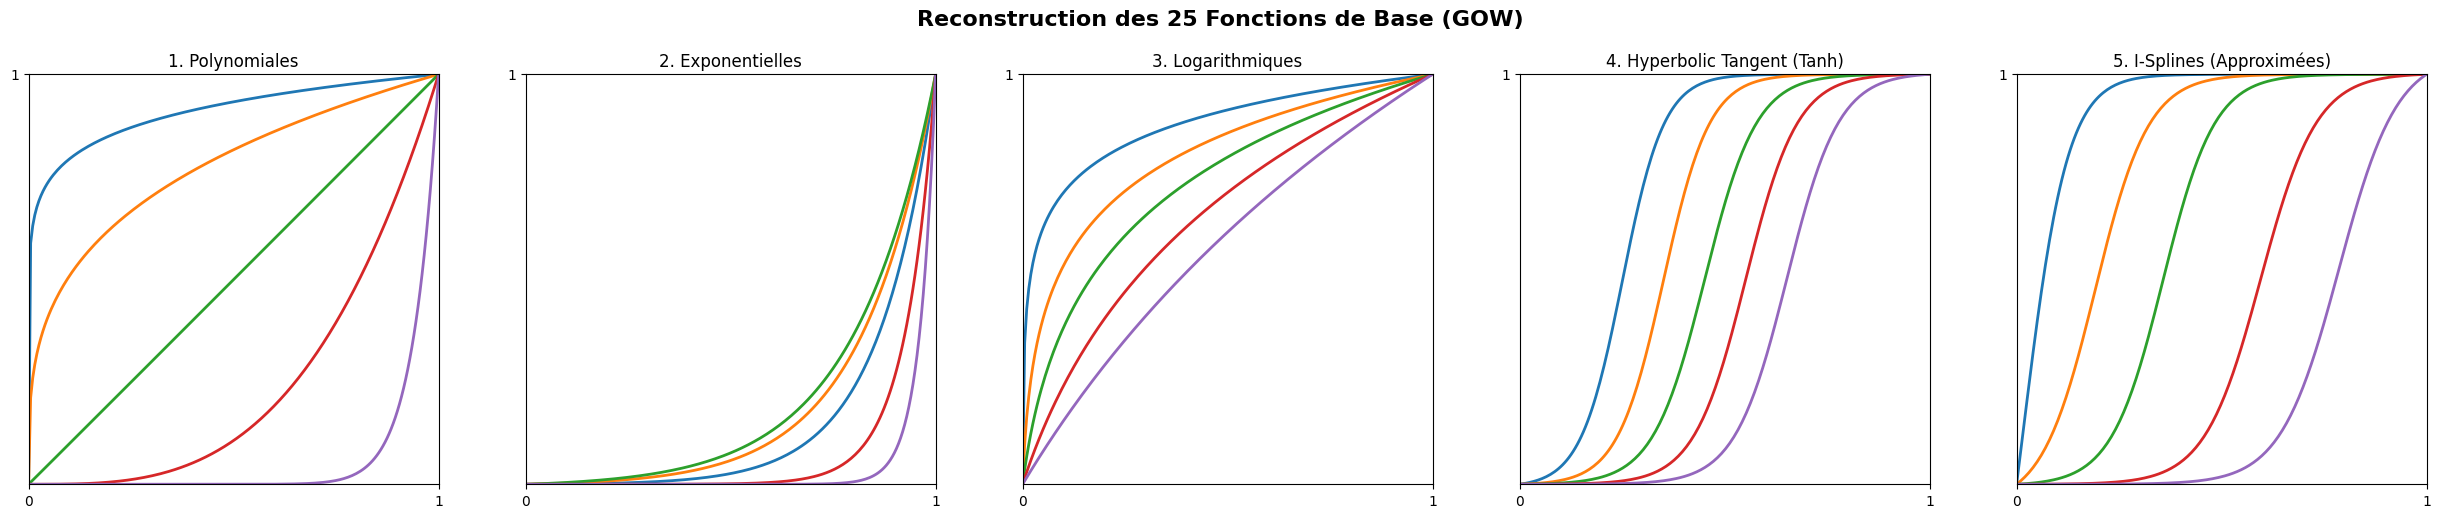

In [ ]:
def plot_5_familles(familles_dict):

    # Correspondance entre le label de famille et la fonction de tracé
    family_to_func = {
        "Polynomiale": norm_poly,
        "Exponentielle": norm_exp,
        "Logarithmique": norm_log,
        "Tanh": norm_tanh,
    }

    # figsize est allongé pour éviter d'écraser les graphes.
    fig, axes = plt.subplots(1, 5, figsize=(25, 5))
    fig.suptitle("Reconstruction des 25 Fonctions de Base (GOW)", fontsize=16, fontweight='bold')
    axes = axes.flatten()
    x_plot = np.linspace(0, 1, 200)

    for i, (nom_famille, fichiers) in enumerate(familles_dict.items()):
        ax = axes[i]
        ax.set_title(nom_famille)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_xticks([0, 1])
        ax.set_yticks([1])
        # force un aspect carré (1 unité en X = 1 unité en Y visuellement)
        ax.set_aspect('equal', adjustable='box')

        print(f"\nANALYSE DE LA FAMILLE : {nom_famille.upper()}")

        for filename, color_plt in fichiers.items():
            try:
                df = pd.read_csv(f"csv/25/{filename}", header=None)
                points = df.values
                points = points[points[:, 0].argsort()]
                x_data, y_data = points[:, 0], points[:, 1]

                function_info, popt, equation, family_label = find_best_fit(x_data, y_data, filename)

                func = family_to_func[family_label]
                y_plot = func(x_plot, *popt)

                ax.plot(x_plot, y_plot, color=color_plt, linewidth=2)
                print(f"[{color_plt}] {filename} -> {equation}")

            except Exception as e:
                print(f"[ERREUR] sur {filename} : {e}")

    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.show()

# 4. LE DICTIONNAIRE GROUPÉ PAR FAMILLE

familles_25 = {
    "1. Polynomiales": {
        'poly_bleu.csv': 'tab:blue',
        'poly_orange.csv': 'tab:orange',
        'poly_vert.csv': 'tab:green',
        'poly_rouge.csv': 'tab:red',
        'poly_violet.csv': 'tab:purple'
    },
    "2. Exponentielles": {
        'exp_bleu.csv': 'tab:blue',
        'exp_orange.csv': 'tab:orange',
        'exp_vert.csv': 'tab:green',
        'exp_rouge.csv': 'tab:red',
        'exp_violet.csv': 'tab:purple'
    },
    "3. Logarithmiques": {
        'log_bleu.csv': 'tab:blue',
        'log_orange.csv': 'tab:orange',
        'log_vert.csv': 'tab:green',
        'log_rouge.csv': 'tab:red',
        'log_violet.csv': 'tab:purple'
    },
    "4. Hyperbolic Tangent (Tanh)": {
        'th_bleu.csv': 'tab:blue',
        'th_orange.csv': 'tab:orange',
        'th_vert.csv': 'tab:green',
        'th_rouge.csv': 'tab:red',
        'th_violet.csv': 'tab:purple'
    },
    "5. I-Splines (Approximées)": {
        'I_bleu.csv': 'tab:blue',
        'I_orange.csv': 'tab:orange', 
        'I_vert.csv': 'tab:green',
        'I_rouge.csv': 'tab:red',
        'I_violet.csv': 'tab:purple'
    }
}


plot_5_familles(familles_25)